In [1]:
import torch
import torchvision
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
#device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')
#print(device)

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [37]:
traindata = CIFAR10(root="./data", download=True, train=True, transform=transform)
trainloader = DataLoader(traindata, shuffle=True, batch_size=8, num_workers=2)
testdata = CIFAR10(root="./data", download=True, train=False, transform=transform)
testloader = DataLoader(testdata, shuffle=False, batch_size=8, num_workers=2)

In [46]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

6


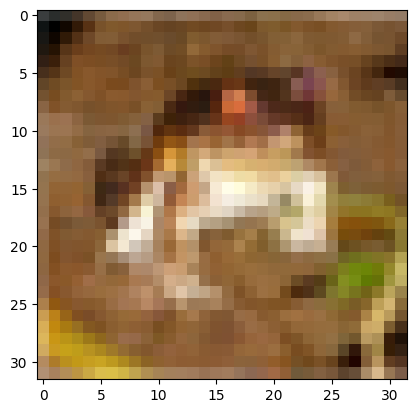

9


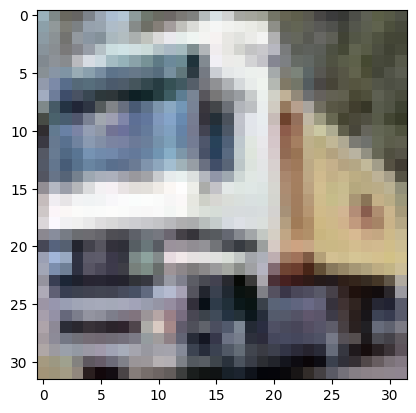

In [34]:
for i in range (2):
  print(traindata[i][1])
  plt.imshow((traindata[i][0].permute(1,2,0)/2)+0.5)
  plt.show()

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)

        return x

In [39]:
model = Model()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

In [41]:
epochs = 5
model.train()

for i in range(epochs):
  epochloss = 0

  for image, label in trainloader:
    output = model(image)
    optimizer.zero_grad()
    loss = loss_func(output, label)
    loss.backward()
    optimizer.step()

    epochloss += loss.item()

  pl = epochloss/len(trainloader)
  print(pl)

tensor(1.7318, grad_fn=<DivBackward0>)
tensor(1.4658, grad_fn=<DivBackward0>)
tensor(1.4062, grad_fn=<DivBackward0>)
tensor(1.4024, grad_fn=<DivBackward0>)
tensor(1.4165, grad_fn=<DivBackward0>)


In [42]:
model.eval()

correct = 0

with torch.no_grad():
  for image, label in testloader:
    output = model(image)
    _, pred = torch.max(output, 1)
    correct += (label == pred).sum().item()

accuracy = 100 * (correct / len(testloader.dataset))
print(f"accuracy: %{accuracy}")

accuracy: %49.63


In [45]:
PATH = './cifar_net.pt'
torch.save(model.state_dict(), PATH)

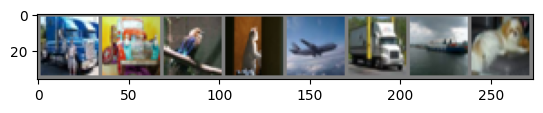

truck truck bird cat plane truck ship dog
truck truck car cat plane truck plane cat


In [52]:
## bonus function to show images

def imshow(img):
  img = img / 2 + 0.5
  plt.imshow(img.permute(1, 2, 0))
  plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
_, pred = torch.max(model(images), 1)
imshow(torchvision.utils.make_grid(images))
print(' '.join(f"{classes[labels[i]]}" for i in range(8)))
print(' '.join(f"{classes[pred[i]]}" for i in range(8)))


In [53]:
a = {classname: 0 for classname in classes}
a["truck"] += 1
print(a)

{'plane': 0, 'car': 0, 'bird': 0, 'cat': 0, 'deer': 0, 'dog': 0, 'frog': 0, 'horse': 0, 'ship': 0, 'truck': 1}


In [64]:
correct_p = {classname: 0 for classname in classes}
total_p= {classname: 0 for classname in classes}

model.eval()

with torch.no_grad():
  for image, label in testloader:
    output = model(image)
    _, pred = torch.max(output, 1)
    for i in label:
      ind = classes[i]
      total_p[str(ind)] += 1

    for i in range(8):
      correct_p[classes[pred[i]]] += (pred[i] == label[i]).item()

print(correct_p)
print(total_p)

{'plane': 505, 'car': 717, 'bird': 308, 'cat': 463, 'deer': 590, 'dog': 136, 'frog': 473, 'horse': 557, 'ship': 789, 'truck': 425}
{'plane': 1000, 'car': 1000, 'bird': 1000, 'cat': 1000, 'deer': 1000, 'dog': 1000, 'frog': 1000, 'horse': 1000, 'ship': 1000, 'truck': 1000}


In [66]:
# my solution is correct but it is not ideal.
# here the author used zip() to enumerate thorugh both labels and predictions

correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')


Accuracy for class: plane is 50.5 %
Accuracy for class: car   is 71.7 %
Accuracy for class: bird  is 30.8 %
Accuracy for class: cat   is 46.3 %
Accuracy for class: deer  is 59.0 %
Accuracy for class: dog   is 13.6 %
Accuracy for class: frog  is 47.3 %
Accuracy for class: horse is 55.7 %
Accuracy for class: ship  is 78.9 %
Accuracy for class: truck is 42.5 %


In [79]:
correct_p = {classname: 0 for classname in classes}
total_p= {classname: 0 for classname in classes}

model.eval()

with torch.no_grad():
  for image, label in testloader:
    output = model(image)
    _, pred = torch.max(output, 1)
    for label, pred in zip(label, pred):
      total_p[classes[label]] += 1
      correct_p[classes[pred]] += (pred == label).item()

print(correct_p)
print(total_p)

{'plane': 505, 'car': 717, 'bird': 308, 'cat': 463, 'deer': 590, 'dog': 136, 'frog': 473, 'horse': 557, 'ship': 789, 'truck': 425}
{'plane': 1000, 'car': 1000, 'bird': 1000, 'cat': 1000, 'deer': 1000, 'dog': 1000, 'frog': 1000, 'horse': 1000, 'ship': 1000, 'truck': 1000}


In [77]:
a = torch.tensor([1,2,3])
b = torch.tensor([4, 5, 6])
for a, b in zip(a,b):
  print(a, b)

tensor(1) tensor(4)
tensor(2) tensor(5)
tensor(3) tensor(6)
